In [2]:
import pandas as pd

# Load the dataset
df = pd.read_csv("combined_data.csv")

# Display first 5 rows
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [3]:
print("Number of rows and columns:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nLabel distribution:")
print(df["label"].value_counts())

Number of rows and columns: (83448, 2)

Column names:
['label', 'text']

Missing values:
label    0
text     0
dtype: int64

Label distribution:
label
1    43910
0    39538
Name: count, dtype: int64


In [4]:
# Check duplicate emails
duplicate_count = df["text"].duplicated().sum()

print("Number of duplicate emails:", duplicate_count)

Number of duplicate emails: 2


In [5]:
# Remove duplicate emails
df = df.drop_duplicates(subset="text").reset_index(drop=True)

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (83446, 2)


In [6]:
print(df["label"].unique())

[1 0]


In [7]:
# Display some legitimate emails
print("----- NOT SPAM -----")
for text in df[df["label"] == 0]["text"].head(3):
    print(text[:500])
    print("\n" + "-" * 80)

# Display some spam emails
print("\n----- SPAM -----")
for text in df[df["label"] == 1]["text"].head(3):
    print(text[:500])
    print("\n" + "-" * 80)

----- NOT SPAM -----
 computer connection from cnn com wednesday escapenumber may escapenumber escapenumber escapenumber escapenumber pm edt in this report next generation toys read brain waves google expands personalization youtube wins webby old fashioned rabbit ears laptop review next generation toys read brain waves a startup company aims to add more realistic elements to video games by using brain wave reading technology to help game developers make gaming more realistic http www cnn com escapenumber tech fun g

--------------------------------------------------------------------------------
thanks for all your answers guys i know i should have checked the rsync manual but i would rather get a escapenumber sure answer from one of you this is my current script bin bash rsync avt \\ exclude alpha \\ exclude arm \\ exclude hppa \\ exclude hurd \\ exclude iaescapenumber \\ exclude mescapenumberk \\ exclude mips \\ exclude mipsel \\ exclude multi arch \\ exclude powerpc \\ exclude sesc

In [8]:
import re
import string

In [9]:
def clean_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)
    
    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)
    
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

In [10]:
df["clean_text"] = df["text"].apply(clean_text)

In [11]:
df[["text", "clean_text"]].head()

,text,clean_text
0,ounce feather bowl hummingbird opec moment ala...,ounce feather bowl hummingbird opec moment ala...
1,wulvob get your medircations online qnb ikud v...,wulvob get your medircations online qnb ikud v...
2,computer connection from cnn com wednesday es...,computer connection from cnn com wednesday esc...
3,university degree obtain a prosperous future m...,university degree obtain a prosperous future m...
4,thanks for all your answers guys i know i shou...,thanks for all your answers guys i know i shou...


In [12]:
empty_count = (df["clean_text"].str.len() == 0).sum()

print("Empty emails:", empty_count)

Empty emails: 10


In [13]:
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

print("Dataset shape:", df.shape)

Dataset shape: (83436, 3)


In [14]:
print("Final columns:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

print("\nSample cleaned emails:")
for text in df["clean_text"].head(5):
    print(text[:300])
    print("-" * 80)

Final columns:
['label', 'text', 'clean_text']

Dataset shape:
(83436, 3)

Sample cleaned emails:
ounce feather bowl hummingbird opec moment alabaster valkyrie dyad bread flack desperate iambic hadron heft quell yoghurt bunkmate divert afterimage
--------------------------------------------------------------------------------
wulvob get your medircations online qnb ikud viagra escapenumber escapenumber levitra escapenumber escapenumber cialis escapenumber escapenumber imitrex escapenumber escapenumber flonax escapenumber escapenumber ultram escapenumber escapenumber vioxx escapenumber escapenumber ambien escapenumber esc
--------------------------------------------------------------------------------
computer connection from cnn com wednesday escapenumber may escapenumber escapenumber escapenumber escapenumber pm edt in this report next generation toys read brain waves google expands personalization youtube wins webby old fashioned rabbit ears laptop review next generation toys read br

In [16]:
import sklearn

print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.9.0


In [17]:
from sklearn.model_selection import train_test_split

X = df["clean_text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training emails:", len(X_train))
print("Testing emails:", len(X_test))

Training emails: 66748
Testing emails: 16688


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=10000
)

# Fit ONLY on training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform test data using the same vectorizer
X_test_tfidf = vectorizer.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (66748, 10000)
Testing TF-IDF shape: (16688, 10000)


In [19]:
from sklearn.naive_bayes import MultinomialNB

# Create the model
nb_model = MultinomialNB()

# Train the model
nb_model.fit(X_train_tfidf, y_train)

print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [20]:
y_pred_nb = nb_model.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [21]:
from sklearn.metrics import accuracy_score

accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Naive Bayes Accuracy:", round(accuracy_nb * 100, 2), "%")

Naive Bayes Accuracy: 97.01 %


In [22]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_nb,
    target_names=["Not Spam", "Spam"]
))

              precision    recall  f1-score   support

    Not Spam       0.96      0.98      0.97      7908
        Spam       0.98      0.96      0.97      8780

    accuracy                           0.97     16688
   macro avg       0.97      0.97      0.97     16688
weighted avg       0.97      0.97      0.97     16688



In [24]:
%pip install matplotlib seaborn

   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.3 MB 6.3 MB/s eta 0:00:02
   ------ --------------------------------- 1.6/9.3 MB 6.0 MB/s eta 0:00:02
   ---------- ----------------------------- 2.4/9.3 MB 4.3 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.3 MB 4.4 MB/s eta 0:00:02
   --------------------- ------------------ 5.0/9.3 MB 5.1 MB/s eta 0:00:01
   --------------------------- ------------ 6.3/9.3 MB 5.1 MB/s eta 0:00:01
   --------------------------------- ------ 7.9/9.3 MB 5.4 MB/s eta 0:00:01
   ---------------------------------------  9.2/9.3 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 5.5 MB/s  0:00:01
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ------------------------------- -------- 1.8/2.4 MB 9.1 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 7.9 MB/s  0:00:00

   ----------------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Confusion Matrix:
[[7721  187]
 [ 312 8468]]


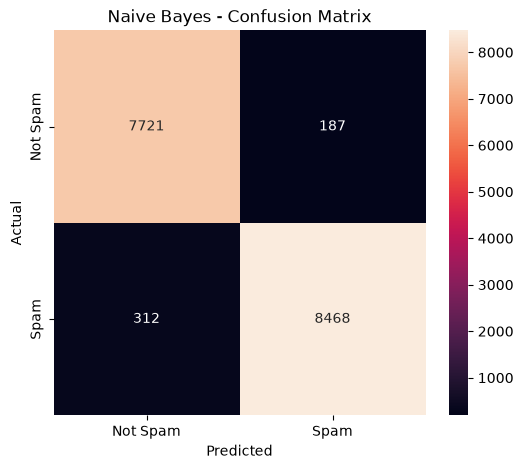

In [26]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_nb)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Spam", "Spam"],
    yticklabels=["Not Spam", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Naive Bayes - Confusion Matrix")

plt.show()

In [27]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

# Train the model
lr_model.fit(X_train_tfidf, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [28]:
y_pred_lr = lr_model.predict(X_test_tfidf)

print("Predictions completed!")

Predictions completed!


In [29]:
from sklearn.metrics import accuracy_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:",
      round(accuracy_lr * 100, 2), "%")

Logistic Regression Accuracy: 98.44 %


In [30]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_lr,
    target_names=["Not Spam", "Spam"]
))

              precision    recall  f1-score   support

    Not Spam       0.99      0.98      0.98      7908
        Spam       0.98      0.99      0.99      8780

    accuracy                           0.98     16688
   macro avg       0.98      0.98      0.98     16688
weighted avg       0.98      0.98      0.98     16688



In [31]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Logistic Regression Confusion Matrix:")
print(cm_lr)

Logistic Regression Confusion Matrix:
[[7724  184]
 [  77 8703]]


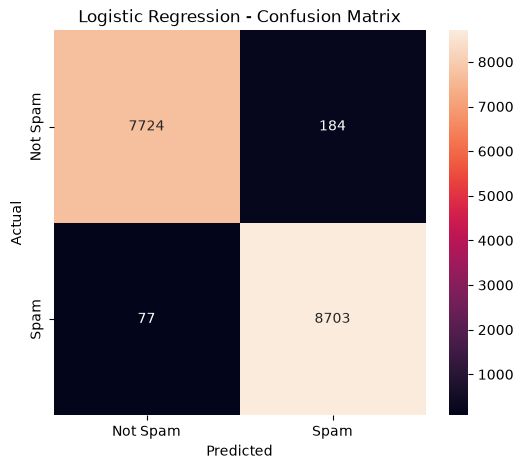

In [32]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    xticklabels=["Not Spam", "Spam"],
    yticklabels=["Not Spam", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

In [33]:
from sklearn.svm import LinearSVC

# Create Linear SVM model
svm_model = LinearSVC()

# Train the model
svm_model.fit(X_train_tfidf, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [34]:
y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM predictions completed!")

SVM predictions completed!


In [35]:
from sklearn.metrics import accuracy_score

accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", round(accuracy_svm * 100, 2), "%")

SVM Accuracy: 98.79 %


In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred_svm,
    target_names=["Not Spam", "Spam"]
))

              precision    recall  f1-score   support

    Not Spam       0.99      0.98      0.99      7908
        Spam       0.99      0.99      0.99      8780

    accuracy                           0.99     16688
   macro avg       0.99      0.99      0.99     16688
weighted avg       0.99      0.99      0.99     16688



In [37]:
from sklearn.metrics import confusion_matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

print("SVM Confusion Matrix:")
print(cm_svm)

SVM Confusion Matrix:
[[7779  129]
 [  73 8707]]


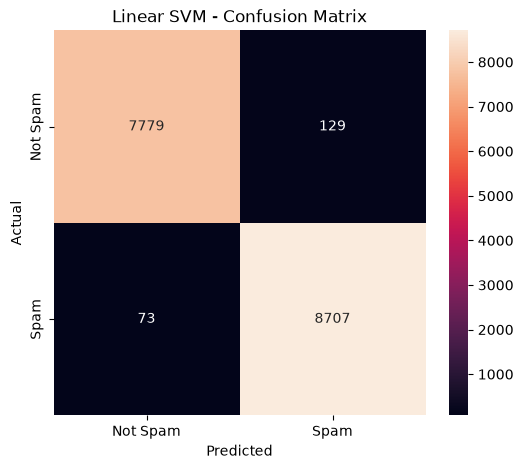

In [38]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=["Not Spam", "Spam"],
    yticklabels=["Not Spam", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Linear SVM - Confusion Matrix")

plt.show()

In [39]:
def predict_email(email):
    # Clean the new email using the same preprocessing
    cleaned_email = clean_text(email)
    
    # Convert to TF-IDF
    email_tfidf = vectorizer.transform([cleaned_email])
    
    # Predict using SVM
    prediction = svm_model.predict(email_tfidf)[0]
    
    if prediction == 1:
        return "SPAM"
    else:
        return "NOT SPAM"

In [40]:
email = """
Congratulations! You have won $1,000,000!
Click here immediately to claim your prize.
"""

print(predict_email(email))

SPAM


In [41]:
email = """
Hi Ravi, please find the project report attached.
We can discuss it tomorrow during class.
"""

print(predict_email(email))

NOT SPAM


In [42]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
import joblib

# Save SVM model
joblib.dump(svm_model, "spam_svm_model.pkl")

# Save TF-IDF vectorizer
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [44]:
import joblib

joblib.dump(svm_model, "spam_svm_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Files saved successfully!")

Files saved successfully!


In [45]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_nb * 100,
        accuracy_lr * 100,
        accuracy_svm * 100
    ]
})

results["Accuracy"] = results["Accuracy"].round(2)

results

,Model,Accuracy
0,Naive Bayes,97.01
1,Logistic Regression,98.44
2,Linear SVM,98.79


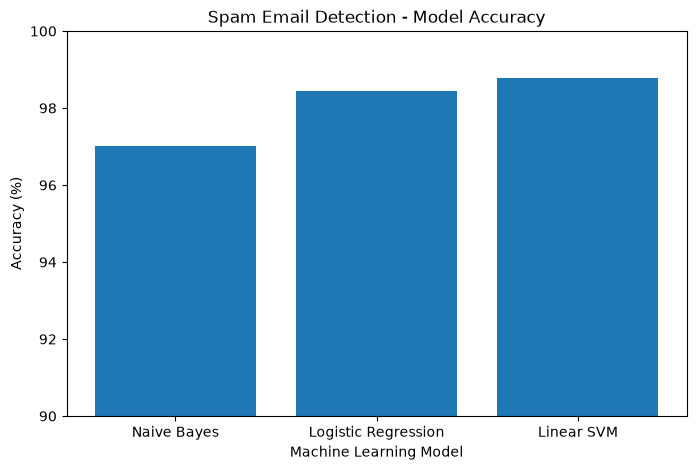

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.title("Spam Email Detection - Model Accuracy")

plt.ylim(90, 100)

plt.show()

In [47]:
best_model = results.loc[
    results["Accuracy"].idxmax()
]

print("Best Model:", best_model["Model"])
print("Best Accuracy:", best_model["Accuracy"], "%")

Best Model: Linear SVM
Best Accuracy: 98.79 %


In [49]:
test_emails = [
    "Congratulations! You have won $5,000. Click here to claim your prize.",
    
    "Dear customer, your bank account has been selected for a special reward. Verify your account immediately.",
    
    "Hi, our project meeting is scheduled for tomorrow at 10 AM.",
    
    "Please find the assignment attached. Submit it before Friday.",
    
    "URGENT! You have been selected for a FREE iPhone. Claim now!"
]

for email in test_emails:
    print("Email:", email)
    print("Prediction:", predict_email(email))
    print("-" * 80)

Email: Congratulations! You have won $5,000. Click here to claim your prize.
Prediction: NOT SPAM
--------------------------------------------------------------------------------
Email: Dear customer, your bank account has been selected for a special reward. Verify your account immediately.
Prediction: SPAM
--------------------------------------------------------------------------------
Email: Hi, our project meeting is scheduled for tomorrow at 10 AM.
Prediction: NOT SPAM
--------------------------------------------------------------------------------
Email: Please find the assignment attached. Submit it before Friday.
Prediction: NOT SPAM
--------------------------------------------------------------------------------
Email: URGENT! You have been selected for a FREE iPhone. Claim now!
Prediction: SPAM
--------------------------------------------------------------------------------


In [50]:
email = "Congratulations! You have won $5,000. Click here to claim your prize."

cleaned_email = clean_text(email)

email_tfidf = vectorizer.transform([cleaned_email])

decision_score = svm_model.decision_function(email_tfidf)

print("SVM decision score:", decision_score[0])

if decision_score[0] >= 0:
    print("Prediction: SPAM")
else:
    print("Prediction: NOT SPAM")

SVM decision score: -0.07292012638834156
Prediction: NOT SPAM
